# Evaluate ComBat!
Can we freeze parameters of ComBat and achieve a similar normalization? What other approach can we take?

In [2]:
import scanpy as sc
import sys
sys.path.append("../..")
from src.training import helpers as tr_h
import logging, numpy as np

# variables
data_path =  "/aloy/home/ddalton/projects/scGPT_playground/data/pp_data-25-08-14-01/data.h5ad"
gene_filtering = "top_presence"
scgpt_pp = "norm_log1p"

# load adata
adata = sc.read_h5ad(data_path)
print("adata loaded")
print(adata.X)

#! REMOVE - THIS IS A QUICK AND UGLY FIX
# only_control = True
# if only_control:
#     adata = adata[adata.obs["doid_id"] != "Control"].copy()

# define celltype as disease
adata.obs["celltype"] = adata.obs["do_id"].astype("category")

# generate celltype label
celltype_id_labels = adata.obs["celltype"].astype("category").cat.codes.values
celltypes = adata.obs["celltype"].unique()
num_types = len(np.unique(celltype_id_labels))
id2type = dict(enumerate(adata.obs["celltype"].astype("category").cat.categories))
adata.obs["celltype_id"] = celltype_id_labels




# gene filtering


if gene_filtering == "top_presence":
    mask_genes = tr_h.get_top_k_most_present_genes(
        adata, k=3501
    )
#! CLEAN UP
elif gene_filtering == "top_logfc":
    def compute_FC(adata)->np.array:
        # Subset by condition
        adata_control = adata[adata.obs["doid_id"] == "Control"]
        adata_disease = adata[adata.obs["doid_id"] != "Control"]

        # Mean expression per group (already log scale)
        mean_control = np.asarray(adata_control.X.mean(axis=0)).flatten()
        mean_disease = np.asarray(adata_disease.X.mean(axis=0)).flatten()

        # log2FC is simply difference of means
        log2fc = mean_disease - mean_control
        return log2fc


    def get_top_k_fc(adata, k=3500):


        total_n_genes = adata.X.shape[1]

        # compute fc
        all_fc = []
        for dsaid in adata.obs["dsaid"].unique():
            adata_dsaid = adata[adata.obs["dsaid"] == dsaid].copy()
            fc = compute_FC(adata_dsaid)
            all_fc.append(fc)

        all_fc = np.array(all_fc)

        # compute presence/absence of counts
        count_presence = np.sum(~np.isnan(adata.X), axis=0)


        # cutoff for top 50% genes by counts
        cutoff = np.percentile(count_presence, 50)
        mask_top = count_presence >= cutoff

        # compute max abs FC per gene
        max_abs_fc = np.nanmean(np.abs(all_fc), axis=0)

        # apply mask
        gene_idx_top = np.where(mask_top)[0]
        fc_sel = max_abs_fc[mask_top]

        # pick top K
        top_local = np.argsort(fc_sel)[::-1][:k]
        selected_idx = gene_idx_top[top_local]


        # boolean mask for the top `k` genes
        mask_top_k = np.zeros(total_n_genes, dtype=bool)
        mask_top_k[selected_idx] = True

        return mask_top_k

    mask_genes = get_top_k_fc(adata, k=3501)



logging.info(f"Combined mask {np.sum(mask_genes)} genes left")

# mask the genes
adata = adata[:, mask_genes]


# mask samples
# non_nan_percentage = np.sum(~np.isnan(adata.X), axis=1) / adata.X.shape[1]
# non_zero_non_nan_mask = ~np.isnan(adata.X) & ~(adata.X == 0)
non_zero_non_nan_mask = ~np.isnan(adata.X) 

non_zero_non_nan_mask_pct = np.sum(non_zero_non_nan_mask, axis=1) / adata.X.shape[1]

# mask samples that have less than 30% non-NaN values
mask_samples = non_zero_non_nan_mask_pct >= 0.3
logging.info(
    f"Filtering out {np.sum(~mask_samples)} / {len(mask_samples)} samples with less than 30% non-NaN values"
)

# apply the mask to the AnnData object
adata = adata[mask_samples, :]


# config parameters
data_is_raw = True
filter_gene_by_counts = False

# perform split
df_obs = adata.obs
new_obs = tr_h.split_stratified(
    df=df_obs,
    y_label="celltype",
    group_label="dataset_id",
    split_size=10,
)
tr_h.report_split(new_obs)
# update observations with new column split
adata.obs = new_obs


INFO:root:Nº genes: 20608, Nº samples: 35626


adata loaded
[[ 2.28181117  0.28048659  7.45157571 ...  2.40383748  5.06200409
   4.63349498]
 [ 2.40082032  0.71559034  6.31002949 ...  1.4395771   4.44380639
   4.52652728]
 [ 2.46996868  0.27068211  6.33381613 ...  0.86830138  4.68736134
   4.89173764]
 ...
 [ 3.49248825  1.16276013  5.35953042 ...  0.69548321  7.11028611
   7.00908272]
 [ 3.5278782   1.17735121 10.7232234  ...  1.00668531  6.80601031
   6.47364488]
 [ 3.44183805  0.49434254  9.94583277 ...  0.86184209  6.70187873
   6.73230078]]


/home/ddalton/Data/old_home/miniconda3/envs/scgpt_2/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
INFO:root:Top 3501 most present genes selected. - >= 35581
INFO:root:Combined mask 3501 genes left
INFO:root:Filtering out 30 / 35626 samples with less than 30% non-NaN values


df shape: (35596, 17)
df diseases: (21231, 17)
Labels: 132 ['Control', 'DOID:0050156', 'DOID:0050700', 'DOID:0060161', 'DOID:0060183', 'DOID:0060488', 'DOID:0080199', 'DOID:0081087', 'DOID:10126', 'DOID:1024', 'DOID:10286', 'DOID:1040', 'DOID:10584', 'DOID:10591', 'DOID:10608', 'DOID:10652', 'DOID:10763', 'DOID:10871', 'DOID:10923', 'DOID:10941', 'DOID:1107', 'DOID:11335', 'DOID:11555', 'DOID:11589', 'DOID:11612', 'DOID:11714', 'DOID:11722', 'DOID:11725', 'DOID:11727', 'DOID:11934', 'DOID:11963', 'DOID:11984', 'DOID:12365', 'DOID:12377', 'DOID:1240', 'DOID:12449', 'DOID:12704', 'DOID:12858', 'DOID:12894', 'DOID:12930', 'DOID:1312', 'DOID:13241', 'DOID:13922', 'DOID:14250', 'DOID:14330', 'DOID:1485', 'DOID:1520', 'DOID:1749', 'DOID:1883', 'DOID:1909', 'DOID:1921', 'DOID:1928', 'DOID:1932', 'DOID:1993', 'DOID:2043', 'DOID:2055', 'DOID:2224', 'DOID:2280', 'DOID:2348', 'DOID:235', 'DOID:2377', 'DOID:2378', 'DOID:2394', 'DOID:2526', 'DOID:2729', 'DOID:2841', 'DOID:289', 'DOID:3044', 'DOID:3

In [3]:
X = adata.X

In [4]:
X

array([[6.59564683, 4.4041416 , 3.96283629, ..., 5.51215518, 6.19616851,
        2.40383748],
       [5.72247986, 4.79475167, 3.81323247, ..., 4.8493347 , 6.19671459,
        1.4395771 ],
       [5.92227548, 4.60411417, 4.7216189 , ..., 5.45023011, 6.03099721,
        0.86830138],
       ...,
       [5.46220194, 4.99559814, 4.00654198, ..., 6.21125282, 7.65306945,
        0.69548321],
       [5.20773404, 4.44317639, 3.61958018, ..., 6.0520568 , 7.32840596,
        1.00668531],
       [5.1593743 , 4.71587656, 3.36216739, ..., 6.01037607, 7.40607007,
        0.86184209]])

In [5]:
import numpy as np
np.isnan(np.power(2, X)).sum()

34635

In [6]:
import sys
sys.path.append("../..")
from src.utils import viz as vz

/home/ddalton/Data/old_home/miniconda3/envs/scgpt_2/lib/python3.12/site-packages/scanpy/preprocessing/_combat.py:351: RuntimeWarning: divide by zero encountered in divide
  (abs(g_new - g_old) / g_old).max(), (abs(d_new - d_old) / d_old).max()


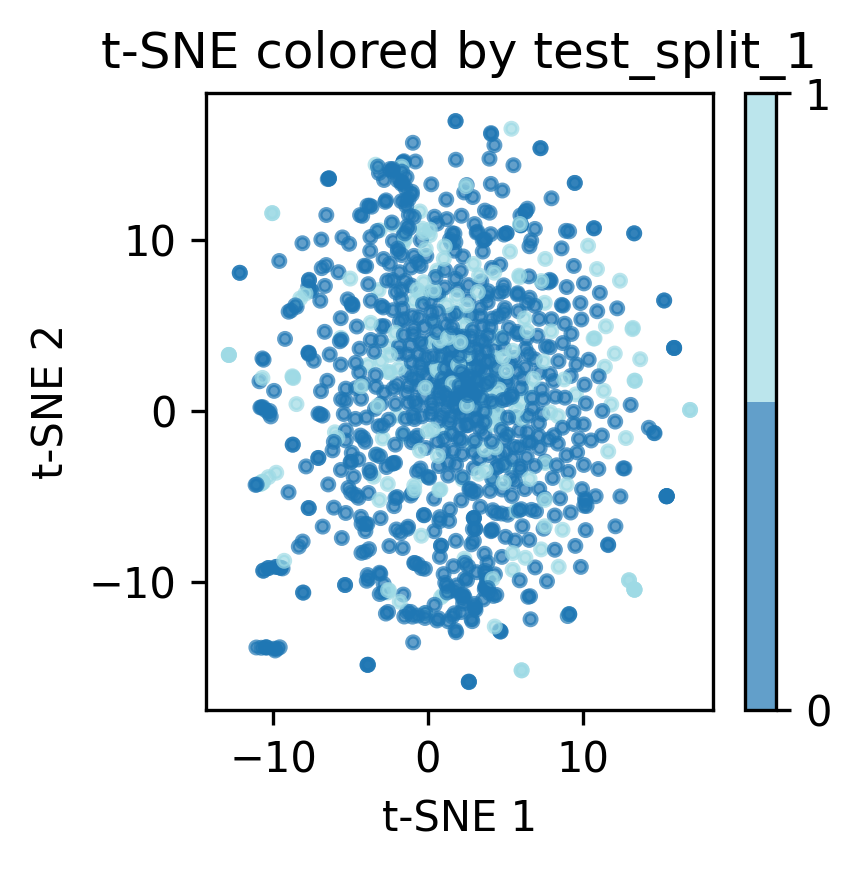

In [8]:
# Approach 1 - apply ComBat to the entire dataset
# perform combat on train & test
adata_combat = tr_h.apply_combat_adata(adata)
vz.plot_tsne_adata(adata_combat, label="test_split_1", sample_size=1000)

/home/ddalton/Data/old_home/miniconda3/envs/scgpt_2/lib/python3.12/site-packages/scanpy/preprocessing/_combat.py:351: RuntimeWarning: divide by zero encountered in divide
  (abs(g_new - g_old) / g_old).max(), (abs(d_new - d_old) / d_old).max()
/home/ddalton/Data/old_home/miniconda3/envs/scgpt_2/lib/python3.12/site-packages/scanpy/preprocessing/_combat.py:351: RuntimeWarning: divide by zero encountered in divide
  (abs(g_new - g_old) / g_old).max(), (abs(d_new - d_old) / d_old).max()
/tmp/ipykernel_2694933/132704316.py:10: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_join = adata_train.concatenate(adata_test)


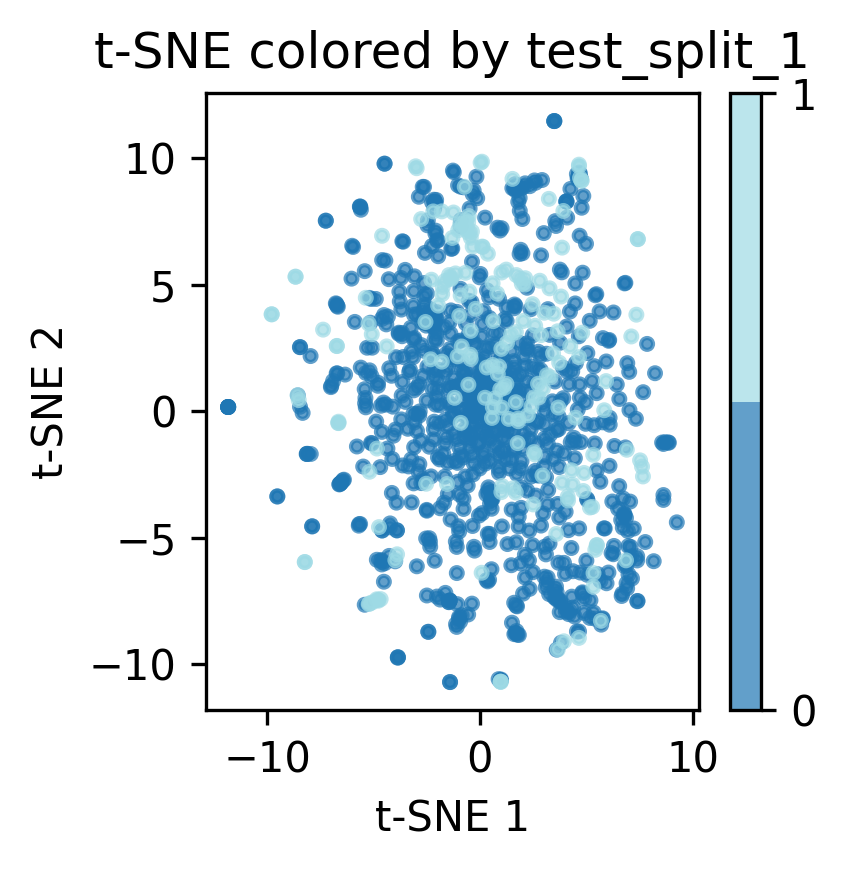

In [9]:
# Approach 2 - apply individual ComBat to each split
# perform combat on train & freeze
adata_train = adata[adata.obs["test_split_1"]==0].copy()
adata_test = adata[adata.obs["test_split_1"]==1].copy()

# apply combat individually
adata_train = tr_h.apply_combat_adata(adata_train)
adata_test = tr_h.apply_combat_adata(adata_test)

adata_join = adata_train.concatenate(adata_test)
vz.plot_tsne_adata(adata_join, label="test_split_1", sample_size=1000)

/home/ddalton/Data/old_home/miniconda3/envs/scgpt_2/lib/python3.12/site-packages/scanpy/preprocessing/_combat.py:351: RuntimeWarning: divide by zero encountered in divide
  (abs(g_new - g_old) / g_old).max(), (abs(d_new - d_old) / d_old).max()
/home/ddalton/Data/old_home/miniconda3/envs/scgpt_2/lib/python3.12/site-packages/scanpy/preprocessing/_combat.py:351: RuntimeWarning: divide by zero encountered in divide
  (abs(g_new - g_old) / g_old).max(), (abs(d_new - d_old) / d_old).max()
/tmp/ipykernel_2694933/1917911334.py:9: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_join = adata_train.concatenate(adata_test)


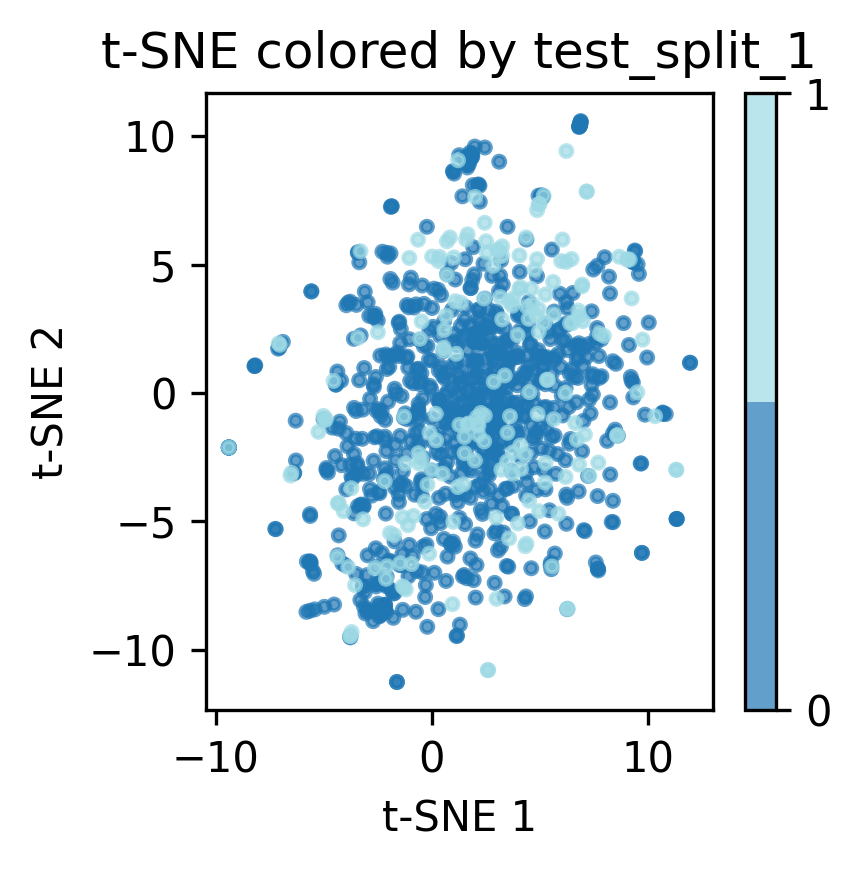

In [ ]:
# Approach 3 - apply combined ComBat
# perform combat on train & freeze
adata_train = adata[adata.obs["test_split_1"]==0].copy()
adata_test = adata[adata.obs["test_split_1"]==1].copy()

# apply combat individually
adata_train = tr_h.apply_combat_adata(adata_train)
adata_test = tr_h.apply_combat_adata(adata_test)
adata_join = adata_train.concatenate(adata_test)
vz.plot_tsne_adata(adata_join, label="test_split_1", sample_size=1000)

In [12]:
adata_combat[adata_combat.obs["test_split_1"]==0].X

ArrayView([[5.62662956, 3.58371921, 0.87396794, ..., 5.47906645,
            5.76358495, 4.12677857],
           [3.90476034, 4.18747474, 0.69847759, ..., 4.3364515 ,
            5.76462554, 2.8112686 ],
           [4.29875363, 3.89281146, 1.76404566, ..., 5.37231582,
            5.44883868, 2.03189519],
           ...,
           [4.77798326, 5.7101193 , 2.19680074, ..., 5.23657876,
            6.30938555, 2.30228377],
           [3.85188028, 3.87327996, 1.43151646, ..., 4.62408902,
            5.36362029, 2.64304773],
           [3.67588127, 4.78002631, 0.92243787, ..., 4.46372685,
            5.58986076, 2.4844455 ]])

In [14]:
adata_train.X

array([[5.56293543, 3.59355165, 0.92116956, ..., 5.50115864, 5.73005971,
        4.04225721],
       [3.88301674, 4.18135   , 0.75249287, ..., 4.37456071, 5.73107032,
        2.74469463],
       [4.26741102, 3.89447463, 1.77668878, ..., 5.39590442, 5.42438299,
        1.97595415],
       ...,
       [4.73385132, 5.66340389, 2.19031191, ..., 5.26289853, 6.25171868,
        2.23757502],
       [3.83255022, 3.87545885, 1.45553262, ..., 4.65856685, 5.34184089,
        2.57610232],
       [3.66126462, 4.75806878, 0.96674642, ..., 4.50034062, 5.55949657,
        2.4185411 ]])